In [1]:
from hybrid_joint import *
from diffrax import *
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from controls import *


In [54]:
H = 0.1
M = 2
grid_points = 10000000
kappa = 1
T = 1.
print(T/grid_points)

1e-07


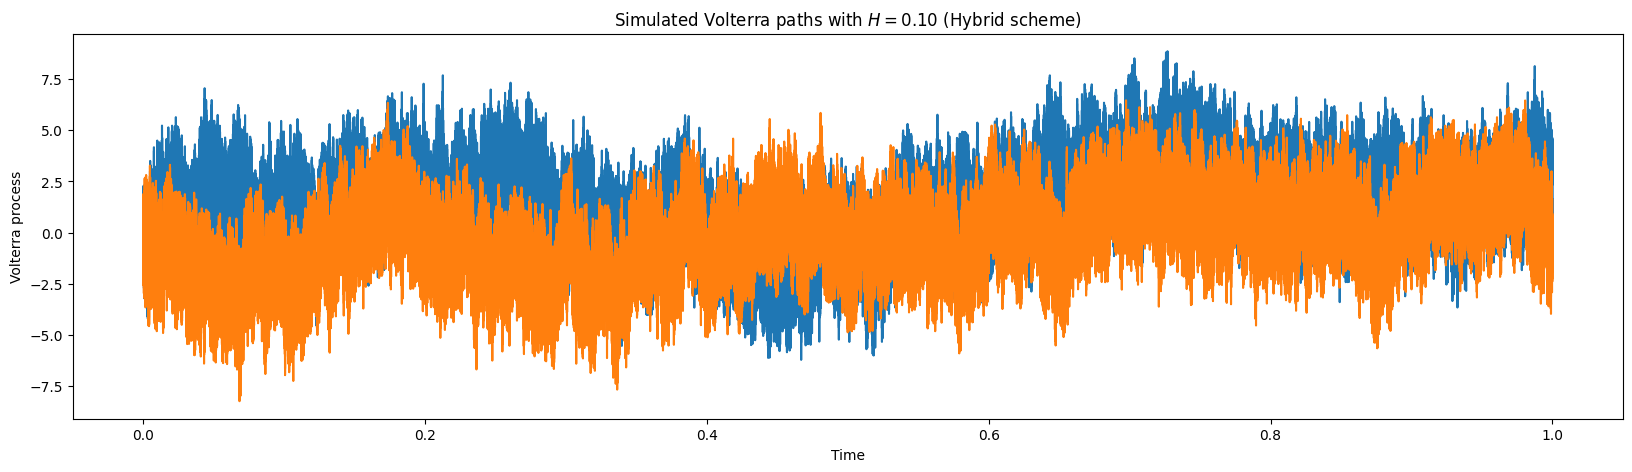

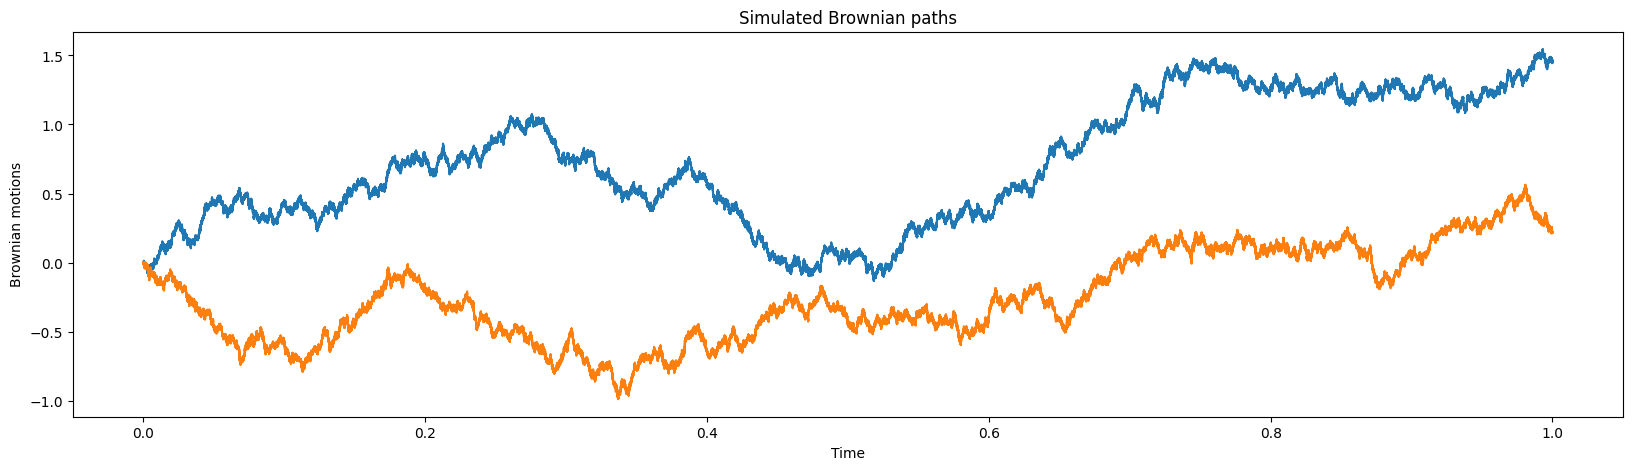

In [55]:
fBmpath, Bmpath = hybrid_scheme(grid_points, M, T, H, kappa)
times = np.linspace(0,T,grid_points)

plt.figure(figsize=(20, 5))
for i in range(M):
    plt.plot(times,fBmpath[i,:]) 
    
plt.xlabel('Time')
plt.ylabel('Volterra process')
plt.title('Simulated Volterra paths with $H=%1.2f$ (Hybrid scheme)'%H)
plt.show()


plt.figure(figsize=(20, 5))
for i in range(M):
    plt.plot(times,Bmpath[i,:]) 
    
    
plt.xlabel('Time')
plt.ylabel('Brownian motions')
plt.title('Simulated Brownian paths')
plt.show()

Let's run some basic checks:

(1) Observe divergence of $\int B^H \circ \mathrm{d} B$ but convergence of $\int B^H \mathrm{d} B$. Also check $\int B^H \mathrm{d} B$ can be obtained with finer grid and lead-lag.

(2) Observe divergence of $\int B^H \circ \mathrm{d} W^K$ for $B^H$ independent of $W^K$ and $H + K \leq 1/2$, but convergence for $H + K > 1/2$ (do $H = K$ and then $H = 0.1$). Also check  $\int B^H \circ \mathrm{d} W^K = \int B^H \mathrm{d} W^K$.

We will simulate the (bm, fbm) pair on a very fine grid (the "true paths"), and then take its piecewise-linear interpolation on a coarser grid. This will give us the freedom of testing convergence as the mesh size of the interpolation $\to 0$.


In [60]:
# Now that we have our "true noise", here are the parameters for subsampling from it
epsilon = 0.000001 # when using fine solver, 0.00001 is the max
every_nth_pt = int(grid_points*epsilon)
times = jnp.arange(0, 1, epsilon)

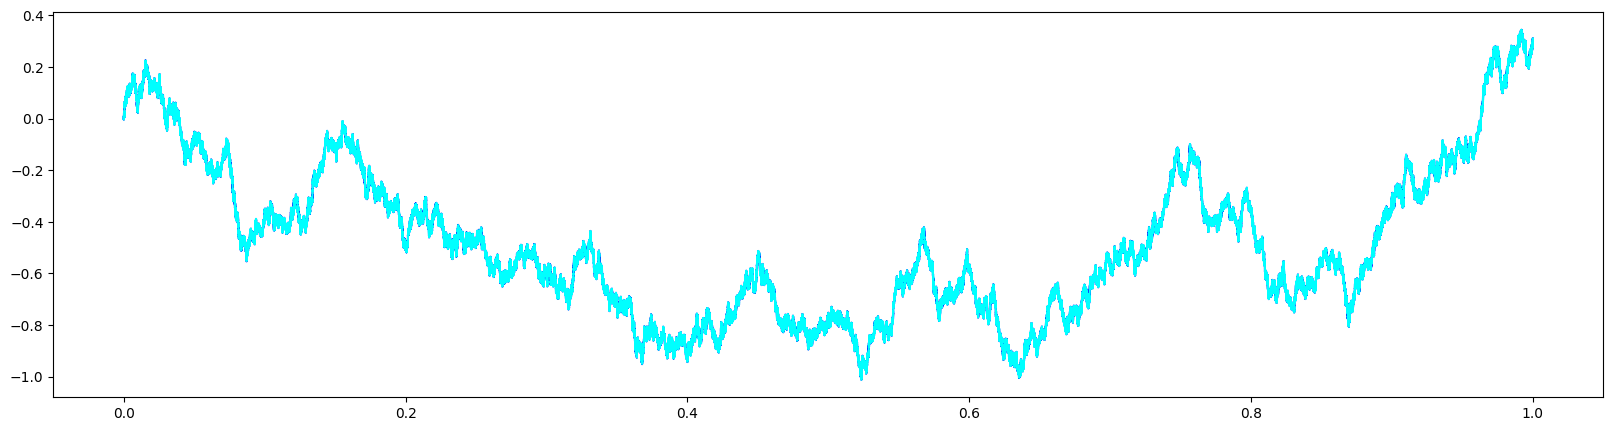

In [40]:
# Create the brownian motion control
subsampled_Bmpath = Bmpath[:, ::every_nth_pt]
bm_interp_0 = LinearInterpolation(times, subsampled_Bmpath[0,:])
bm_interp_1 = LinearInterpolation(times, subsampled_Bmpath[1,:])
def evaluate_and_reshape(interp):
    return lambda s,t: jnp.atleast_1d(interp(s,t))
bm_interp_0_reshaped = evaluate_and_reshape(bm_interp_0.evaluate)
bm_interp_1_reshaped = evaluate_and_reshape(bm_interp_1.evaluate)
bm_control = join_controls(bm_interp_0_reshaped, bm_interp_1_reshaped)

# check that they are similar to the original
plt.figure(figsize=(20, 5))
fine_times = jnp.linspace(0, 1, grid_points)
plt.plot(fine_times, Bmpath[1,:], color = 'blue')
plt.plot(times, subsampled_Bmpath[1,:], color = 'cyan')

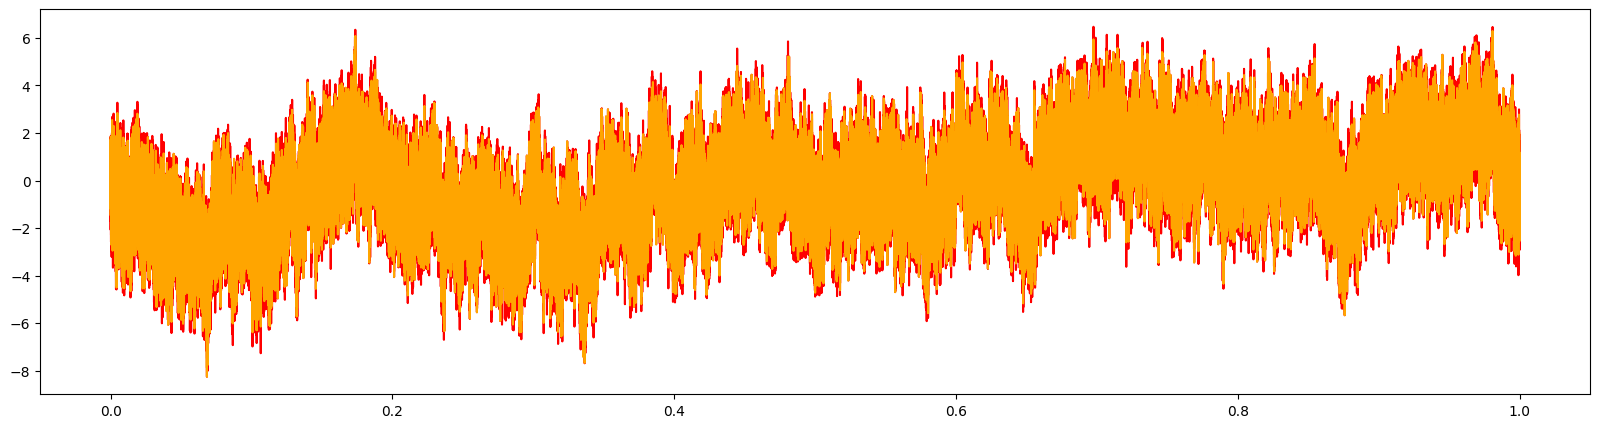

In [61]:
# Create the fbm control
subsampled_fBmpath = fBmpath[:, ::every_nth_pt]
fbm_interp_0 = LinearInterpolation(times, subsampled_fBmpath[0,:])
fbm_interp_1 = LinearInterpolation(times, subsampled_fBmpath[1,:])
fbm_interp_0_reshaped = evaluate_and_reshape(fbm_interp_0.evaluate)
fbm_interp_1_reshaped = evaluate_and_reshape(fbm_interp_1.evaluate)
fbm_control = join_controls(fbm_interp_0_reshaped, fbm_interp_1_reshaped)

# check that they are similar to the original
plt.figure(figsize=(20, 5))
fine_times = jnp.linspace(0, 1, grid_points)
plt.plot(fine_times, fBmpath[1,:], color = 'red')
plt.plot(times, subsampled_fBmpath[1,:], color = 'orange')

In [12]:
# (1) We look at Stratonovich and Ito integrals of B^H dB. Start with Stratonovich. To observe divergence, we need to take finer epsilon above.

saveat = SaveAt(ts = times)
solver_epsilon = 0.01*epsilon

joint_same_control = join_controls(fbm_interp_0_reshaped, bm_interp_0_reshaped)

y0 = jnp.array([0,0])
diffusion_int01 = lambda t, y, args: jnp.array([[1,0], [0,y[0]]])
terms = MultiTerm(ControlTerm(diffusion_int01, joint_same_control))
solutions_same_strat = diffeqsolve(terms, Euler(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

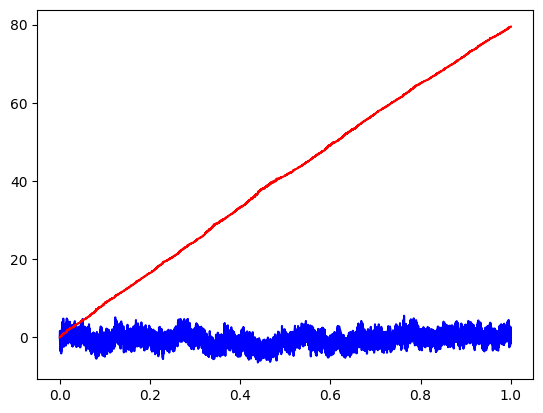

In [13]:
plt.plot(solutions_same_strat.ts[:], solutions_same_strat.ys[:, 0], color = "blue")
plt.plot(solutions_same_strat.ts[:], solutions_same_strat.ys[:, 1], color = "red")

# Indeed, the mean blows up as epsilon -> 0

In [22]:
# Now Ito

saveat = SaveAt(ts = times)
solver_epsilon = epsilon

lagged = lagged_control(fbm_interp_0.evaluate, epsilon)
lagged = evaluate_and_reshape(lagged)
joint_same_control = join_controls(lagged, bm_interp_0_reshaped)

y0 = jnp.array([0,0])
diffusion_int01 = lambda t, y, args: jnp.array([[1,0], [0,y[0]]])
terms = MultiTerm(ControlTerm(diffusion_int01, joint_same_control))
solutions_same_ito = diffeqsolve(terms, Euler(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

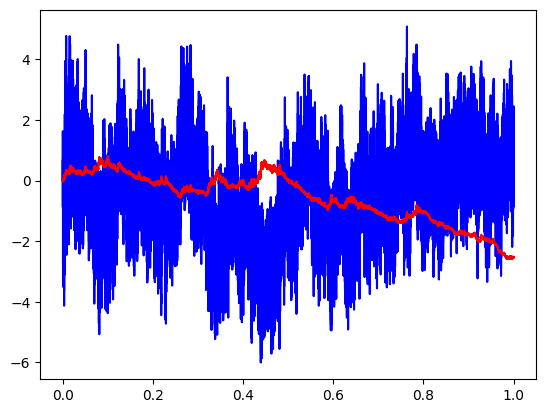

In [23]:
plt.plot(solutions_same_ito.ts[:], solutions_same_ito.ys[:, 0], color = "blue")
plt.plot(solutions_same_ito.ts[:], solutions_same_ito.ys[:, 1], color = "red")

# To get convergence it was necessary to lag the integrand. This shouldn't have been necessary - probably all the interpolating/subsampling is causing the path to
# "see into the future", which is generating the divergent quadratic variation. It might be challenging to find a good baseline for Ito integration.

In [24]:
# (2) First let's test convergence of the integral B^H dW

subsampled_Bmpath = Bmpath[:, ::every_nth_pt]
bm_interp_0 = LinearInterpolation(times, subsampled_Bmpath[0,:])
bm_interp_0_reshaped = evaluate_and_reshape(bm_interp_0.evaluate)

subsampled_fBmpath = fBmpath[:, ::every_nth_pt]
fbm_interp_1 = LinearInterpolation(times, subsampled_fBmpath[1,:])
fbm_interp_1_reshaped = evaluate_and_reshape(fbm_interp_1.evaluate)

joint_ind_control = join_controls(fbm_interp_1_reshaped, bm_interp_0_reshaped)

solver_epsilon = epsilon # this seems sufficient, but we need to validate this properly
saveat = SaveAt(ts = times)

y0 = jnp.array([0,0])
diffusion_int01 = lambda t, y, args: jnp.array([[1,0], [0,y[0]]])
terms = MultiTerm(ControlTerm(diffusion_int01, joint_ind_control))
solutions_ind_bm = diffeqsolve(terms, Euler(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

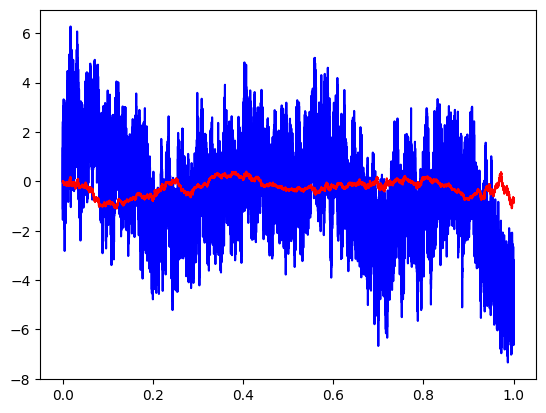

In [25]:
plt.plot(solutions_ind_bm.ts[:], solutions_ind_bm.ys[:, 0], color = "blue")
plt.plot(solutions_ind_bm.ts[:], solutions_ind_bm.ys[:, 1], color = "red")

# we have convergence

In [42]:
# (2) Now let's test convergence of the integral B^H dW^K for H = K = 0.3 (go back up and resample)

subsampled_fBmpath = fBmpath[:, ::every_nth_pt]
fbm_interp_0 = LinearInterpolation(times, subsampled_fBmpath[0,:])
fbm_interp_0_reshaped = evaluate_and_reshape(fbm_interp_0.evaluate)

subsampled_fBmpath = fBmpath[:, ::every_nth_pt]
fbm_interp_1 = LinearInterpolation(times, subsampled_fBmpath[1,:])
fbm_interp_1_reshaped = evaluate_and_reshape(fbm_interp_1.evaluate)

joint_ind_control = join_controls(fbm_interp_0_reshaped, fbm_interp_1_reshaped)

solver_epsilon = epsilon
saveat = SaveAt(ts = times)

y0 = jnp.array([0,0])
diffusion_int01 = lambda t, y, args: jnp.array([[1,0], [0,y[0]]])
terms = MultiTerm(ControlTerm(diffusion_int01, joint_ind_control))
solutions_ind_fbm_conv = diffeqsolve(terms, Midpoint(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

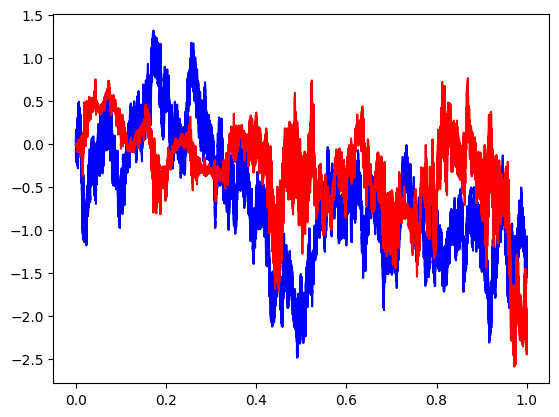

In [43]:
plt.plot(solutions_ind_fbm_conv.ts[:], solutions_ind_fbm_conv.ys[:, 0], color = "blue")
plt.plot(solutions_ind_fbm_conv.ts[:], solutions_ind_fbm_conv.ys[:, 1], color = "red")

# converges

In [62]:
# Divergence of the integral B^H dW^K for H = K < 2.5 (take 0.1 for the clearest behaviour)

subsampled_fBmpath = fBmpath[:, ::every_nth_pt]
fbm_interp_0 = LinearInterpolation(times, subsampled_fBmpath[0,:])
fbm_interp_0_reshaped = evaluate_and_reshape(fbm_interp_0.evaluate)

subsampled_fBmpath = fBmpath[:, ::every_nth_pt]
fbm_interp_1 = LinearInterpolation(times, subsampled_fBmpath[1,:])
fbm_interp_1_reshaped = evaluate_and_reshape(fbm_interp_1.evaluate)

joint_ind_control = join_controls(fbm_interp_0_reshaped, fbm_interp_1_reshaped)

solver_epsilon = epsilon
saveat = SaveAt(ts = times)

y0 = jnp.array([0,0])
diffusion_int01 = lambda t, y, args: jnp.array([[1,0], [0,y[0]]])
terms = MultiTerm(ControlTerm(diffusion_int01, joint_ind_control))
solutions_ind_fbm_div = diffeqsolve(terms, Midpoint(), 0, 1, dt0 = solver_epsilon, max_steps=None, y0=y0, saveat=saveat)

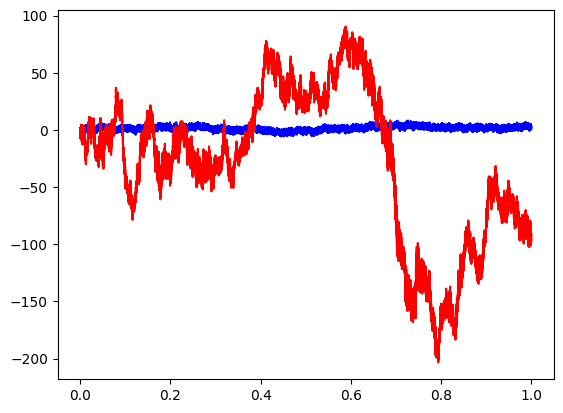

In [63]:
plt.plot(solutions_ind_fbm_div.ts[:], solutions_ind_fbm_div.ys[:, 0], color = "blue")
plt.plot(solutions_ind_fbm_div.ts[:], solutions_ind_fbm_div.ys[:, 1], color = "red")

# appears to diverge in variance (best seen across samples but also visible within a single sample)

Some more optional tests to try in the future:

- Check $\int B^H \mathrm{d} B^H$ diverges for $H < 1/2$ but $\int B^H \circ \mathrm{d} B^H$ converges to $(B^H)^2/2$
- Check $\int B^H \circ \mathrm{d} B^K$ (fully correlated) diverges for $K \neq 1/2$ and $H + K \leq 1$ (case not tested so far: $H + K > 1/2$, so for example $H = 1/3$ and $K = 2/3$). The code would have to be rewritten for this test though.
- In the independent case with $H + K \leq 1/2$ you can get convergence in distribution by multiplying by $C_\varepsilon$ as in Hairer's paper.

Next, we have to test equations:

- Rough Bergomi, with $W$ and $B^H$ correlated. Model already exists. Solve with lead-lag and test against existing scheme.
- Quadratic rough Heston, only one factor. New model. Full rough path not necessary ("partial rough path" enough) but interesting theoretically. Solve with lead-lag and test is the same as solving first vol then price.
- "Dynamics of stoch vol" model, with $W$ and $B^H$ independent. New model based on gaussian rough paths. Lead-lag not relevant. Test convergence.
- A case in which lead-lag is really necessary. This could be "Dynamics of stoch vol" with various correlation structures between the three driving signals. The simplest is to take $W^1 = W^2$ and correlation between $W^1$ and $B^H$. Test convergence.